In [163]:
import inspect
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from helper_functions import *

In [164]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
experiment_dir = 'Gaussian_Dist_Errors/Software_Timestamping_RTOS_IMU_Between_Minus_Positive'

In [165]:
freq = '4Hz'

In [166]:
folders = next(os.walk(f'{base_dir}/{experiment_dir}'))[1]

In [167]:
folders

['2000us_6Hz',
 '10us_4Hz',
 '5us_6Hz',
 '1000us_6Hz',
 '2.5us_6Hz',
 '20us_4Hz',
 '1us_6Hz',
 '1us_4Hz',
 '100us_6Hz',
 '100us_4Hz',
 '500us_4Hz',
 '50us_6Hz',
 '750us_4Hz',
 '7.5us_6Hz',
 '500us_6Hz',
 '250us_4Hz',
 '2.5us_4Hz',
 '2000us_4Hz',
 '1500us_4Hz',
 '10us_6Hz',
 '20us_6Hz',
 '1500us_6Hz',
 '750us_6Hz',
 '1000us_4Hz',
 '50us_4Hz',
 '5us_4Hz',
 '7.5us_4Hz',
 '250us_6Hz']

In [168]:
dfs = []
execution_index = 3

for index, execution_folder_name in enumerate(folders):
    print(execution_folder_name)
    df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_vio.csv')
    df['Execution'] = execution_folder_name
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

2000us_6Hz
10us_4Hz
5us_6Hz
1000us_6Hz
2.5us_6Hz
20us_4Hz
1us_6Hz
1us_4Hz
100us_6Hz
100us_4Hz
500us_4Hz
50us_6Hz
750us_4Hz
7.5us_6Hz
500us_6Hz
250us_4Hz
2.5us_4Hz
2000us_4Hz
1500us_4Hz
10us_6Hz
20us_6Hz
1500us_6Hz
750us_6Hz
1000us_4Hz
50us_4Hz
5us_4Hz
7.5us_4Hz
250us_6Hz


In [169]:
gt_df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_gt.csv')
gt_df['Execution'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [170]:
gt_df.shape

(22401, 18)

In [171]:
all_executions = pd.concat(dfs)

In [172]:
all_executions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 35419 entries, 0 to 22400
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  35419 non-null  int64  
 1   x          35419 non-null  float64
 2   y          35419 non-null  float64
 3   z          35419 non-null  float64
 4   qw         35419 non-null  float64
 5   qx         35419 non-null  float64
 6   qy         35419 non-null  float64
 7   qz         35419 non-null  float64
 8   vx         35419 non-null  float64
 9   vy         35419 non-null  float64
 10  vz         35419 non-null  float64
 11  bgx        35419 non-null  float64
 12  bgy        35419 non-null  float64
 13  bgz        35419 non-null  float64
 14  bax        35419 non-null  float64
 15  bay        35419 non-null  float64
 16  baz        35419 non-null  float64
 17  Execution  35419 non-null  object 
dtypes: float64(16), int64(1), object(1)
memory usage: 5.1+ MB


In [173]:
sns.set_theme(rc={'figure.figsize':(12,6)})

In [174]:
# Consider only the 4hz or 6Hz data for plotting and investigation.
folders_to_consider = []

for folder_name in folders:
    if freq in folder_name:
        folders_to_consider.append(folder_name)

In [175]:
folders_to_consider

['10us_4Hz',
 '20us_4Hz',
 '1us_4Hz',
 '100us_4Hz',
 '500us_4Hz',
 '750us_4Hz',
 '250us_4Hz',
 '2.5us_4Hz',
 '2000us_4Hz',
 '1500us_4Hz',
 '1000us_4Hz',
 '50us_4Hz',
 '5us_4Hz',
 '7.5us_4Hz']

In [176]:
import re

def sort_folders_by_number(folder_names, apply_sorting=True):
    def extract_number(folder_name):
        match = re.fullmatch(fr'([\d.]+)us_{freq}', folder_name)
        return float(match.group(1)) if match else float('inf')  # Use infinity if no match
    # Sort the list based on the extracted number
    if apply_sorting:
        return sorted(folder_names, key=extract_number, reverse=True)
    else:
        return folder_names

In [177]:
sorted_folders = sort_folders_by_number(folders_to_consider, True)
print(sorted_folders)

['2000us_4Hz', '1500us_4Hz', '1000us_4Hz', '750us_4Hz', '500us_4Hz', '250us_4Hz', '100us_4Hz', '50us_4Hz', '20us_4Hz', '10us_4Hz', '7.5us_4Hz', '5us_4Hz', '2.5us_4Hz', '1us_4Hz']


In [178]:
sorted_folders.append('GT')

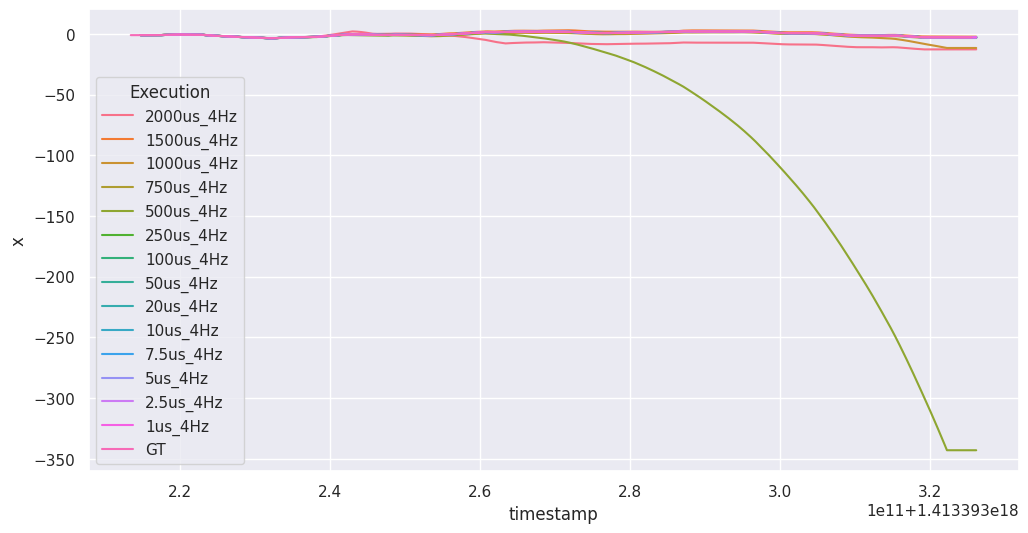

In [179]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution', hue_order = sorted_folders)
# ax.set(ylim=(-4, 4))

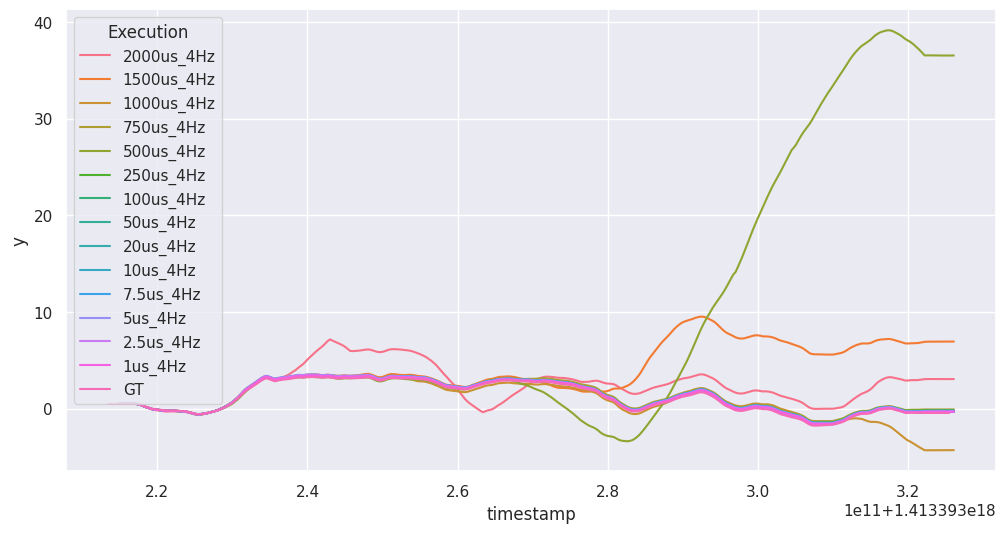

In [180]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution', hue_order = sorted_folders)
# ax.set(ylim=(-4, 4))

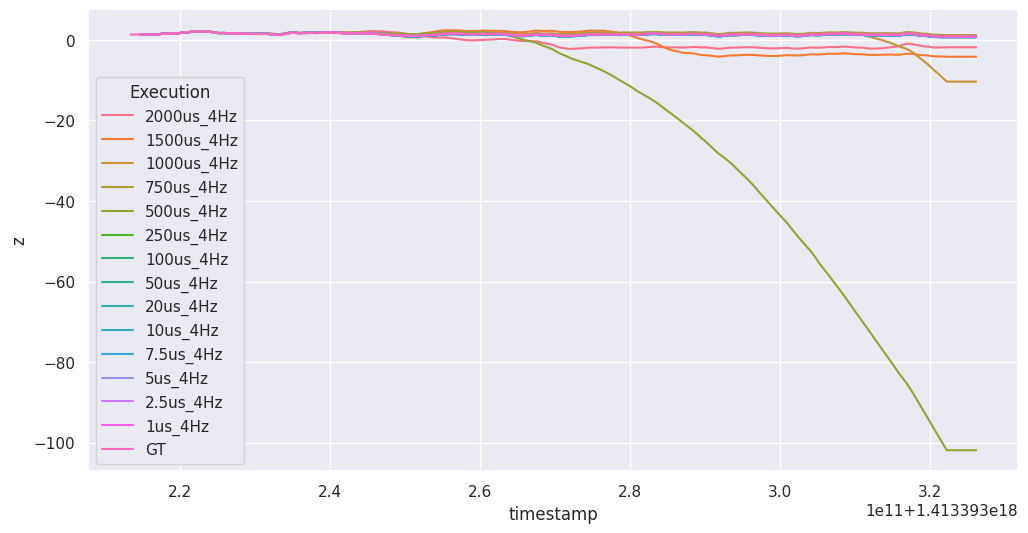

In [181]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution', hue_order = sorted_folders)

In [182]:
np.set_printoptions(precision=20)
pd.set_option('display.float_format', '{:.20f}'.format)

In [183]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for df in dfs:
    error_df = generate_error_gt_vio_pose(gt_df, df, DEBUG=False, SHOW_GRAPHS=False)
    values[df.iloc[0]['Execution']] = {
                'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

558
372
558
558
558
372
558
372
558
372
372
558
372
558
557
372
372
372
372
558
558
558
558
372
372
372
372
557
22401


In [184]:
values.keys()

dict_keys(['2000us_6Hz', '10us_4Hz', '5us_6Hz', '1000us_6Hz', '2.5us_6Hz', '20us_4Hz', '1us_6Hz', '1us_4Hz', '100us_6Hz', '100us_4Hz', '500us_4Hz', '50us_6Hz', '750us_4Hz', '7.5us_6Hz', '500us_6Hz', '250us_4Hz', '2.5us_4Hz', '2000us_4Hz', '1500us_4Hz', '10us_6Hz', '20us_6Hz', '1500us_6Hz', '750us_6Hz', '1000us_4Hz', '50us_4Hz', '5us_4Hz', '7.5us_4Hz', '250us_6Hz', 'GT'])

In [185]:
error_distance_dfs = []

for i in values.keys():
    err_df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution':i})
    error_distance_dfs.append(err_df)

error_distance_dfs = pd.concat(error_distance_dfs)

In [186]:
error_distance_dfs['Execution'].unique()

array(['2000us_6Hz', '10us_4Hz', '5us_6Hz', '1000us_6Hz', '2.5us_6Hz',
       '20us_4Hz', '1us_6Hz', '1us_4Hz', '100us_6Hz', '100us_4Hz',
       '500us_4Hz', '50us_6Hz', '750us_4Hz', '7.5us_6Hz', '500us_6Hz',
       '250us_4Hz', '2.5us_4Hz', '2000us_4Hz', '1500us_4Hz', '10us_6Hz',
       '20us_6Hz', '1500us_6Hz', '750us_6Hz', '1000us_4Hz', '50us_4Hz',
       '5us_4Hz', '7.5us_4Hz', '250us_6Hz', 'GT'], dtype=object)

In [187]:
# sorted_folders.remove("100us_6Hz")
# sorted_folders.remove("50us_6Hz")
# sorted_folders.remove("10us_6Hz")
# sorted_folders.insert(0, "7.5us_6Hz")

In [188]:
sorted_folders

['2000us_4Hz',
 '1500us_4Hz',
 '1000us_4Hz',
 '750us_4Hz',
 '500us_4Hz',
 '250us_4Hz',
 '100us_4Hz',
 '50us_4Hz',
 '20us_4Hz',
 '10us_4Hz',
 '7.5us_4Hz',
 '5us_4Hz',
 '2.5us_4Hz',
 '1us_4Hz',
 'GT']

(0.0, 5.0)

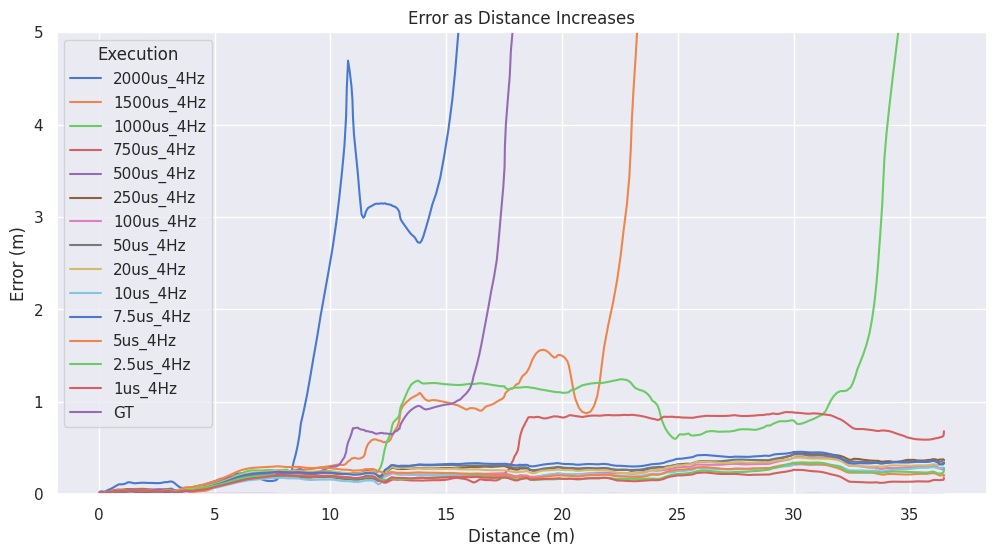

In [190]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases'

g = sns.lineplot(data = error_distance_dfs,
                 x='Distance (m)', 
                 y = 'Error (m)', 
                 hue='Execution', 
                 legend='full', 
                 palette='muted', 
                 hue_order = sorted_folders[:])
g.set_title(title)
g.set_ylim(0, 5)

## Filtering

In [194]:
sorted_folders[:7]

['2000us_4Hz',
 '1500us_4Hz',
 '1000us_4Hz',
 '750us_4Hz',
 '500us_4Hz',
 '250us_4Hz',
 '100us_4Hz']

In [195]:
filtered_folders = sorted_folders[:7]

In [196]:
error_distance_dfs_filtered = error_distance_dfs[error_distance_dfs['Execution'].isin(filtered_folders)]

In [197]:
error_distance_dfs_filtered

,Distance (m),Error (m),Execution
0,0.00000000000000000000,0.00005741950887992281,100us_4Hz
1,0.00216703918847342561,0.00142438621432436764,100us_4Hz
2,0.00427963814079077541,0.00198466198386323435,100us_4Hz
3,0.00671379515729749170,0.00320010972586835807,100us_4Hz
4,0.00964363264580334230,0.00408136040872387595,100us_4Hz
...,...,...,...
365,36.48450904086612922583,14.81106470832862598286,1000us_4Hz
366,36.48512894831694097775,14.80963720756348145358,1000us_4Hz
367,36.48569442743733048928,14.80856657668186926458,1000us_4Hz
368,36.48625477436124242558,14.80769320989726089977,1000us_4Hz


(0.0, 5.0)

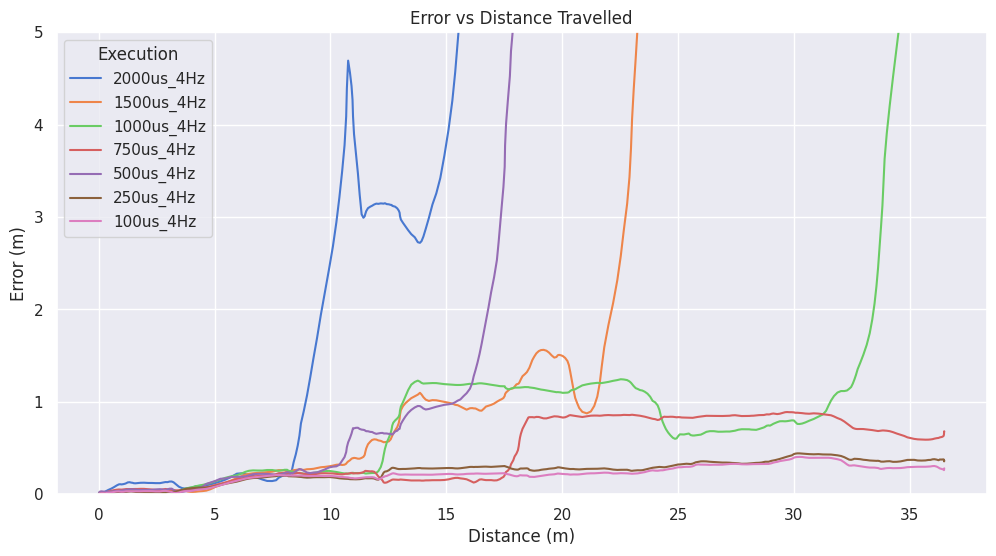

In [199]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error vs Distance Travelled'

g = sns.lineplot(data = error_distance_dfs_filtered, x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted', hue_order = filtered_folders)
g.set_title(title)
g.set_ylim(0, 5)